In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cleaned data load karo
df = pd.read_csv('../data/IPL_cleaned.csv', parse_dates=['date'])

print(df.shape)
df.head()

(278205, 30)


,match_id,date,season,match_type,venue,city,innings,batting_team,bowling_team,over,...,toss_winner,toss_decision,team_runs,team_balls,team_wicket,runs_target,match_won_by,win_outcome,result_type,player_of_match
0,335982,2008-04-18,2008,T20,"M Chinnaswamy Stadium, Bengaluru",Bengaluru,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,...,Royal Challengers Bangalore,field,1,1,0,NaN,Kolkata Knight Riders,140 runs,NaN,BB McCullum
1,335982,2008-04-18,2008,T20,"M Chinnaswamy Stadium, Bengaluru",Bengaluru,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,...,Royal Challengers Bangalore,field,1,2,0,NaN,Kolkata Knight Riders,140 runs,NaN,BB McCullum
2,335982,2008-04-18,2008,T20,"M Chinnaswamy Stadium, Bengaluru",Bengaluru,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,...,Royal Challengers Bangalore,field,2,2,0,NaN,Kolkata Knight Riders,140 runs,NaN,BB McCullum
3,335982,2008-04-18,2008,T20,"M Chinnaswamy Stadium, Bengaluru",Bengaluru,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,...,Royal Challengers Bangalore,field,2,3,0,NaN,Kolkata Knight Riders,140 runs,NaN,BB McCullum
4,335982,2008-04-18,2008,T20,"M Chinnaswamy Stadium, Bengaluru",Bengaluru,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,...,Royal Challengers Bangalore,field,2,4,0,NaN,Kolkata Knight Riders,140 runs,NaN,BB McCullum


# Season wise total runs

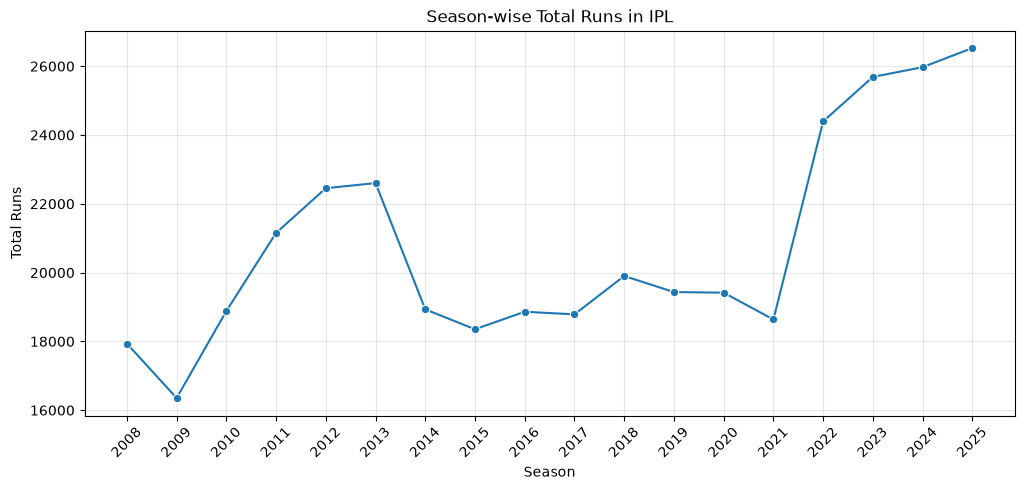

In [21]:
season_runs = df.groupby('season')['runs_total'].sum()


plt.figure(figsize=(12,5))
sns.lineplot(x =season_runs.index , y=season_runs.values, marker = 'o')
plt.title("Season-wise Total Runs in IPL")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.xticks(season_runs.index, rotation = 45)
plt.grid(alpha = 0.3)
plt.show()

# Top 10 Runs scorers (career)

C:\Users\KARUNYA\AppData\Local\Temp\ipykernel_12904\3749072710.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scorers.values, y=top_scorers.index, palette='viridis')


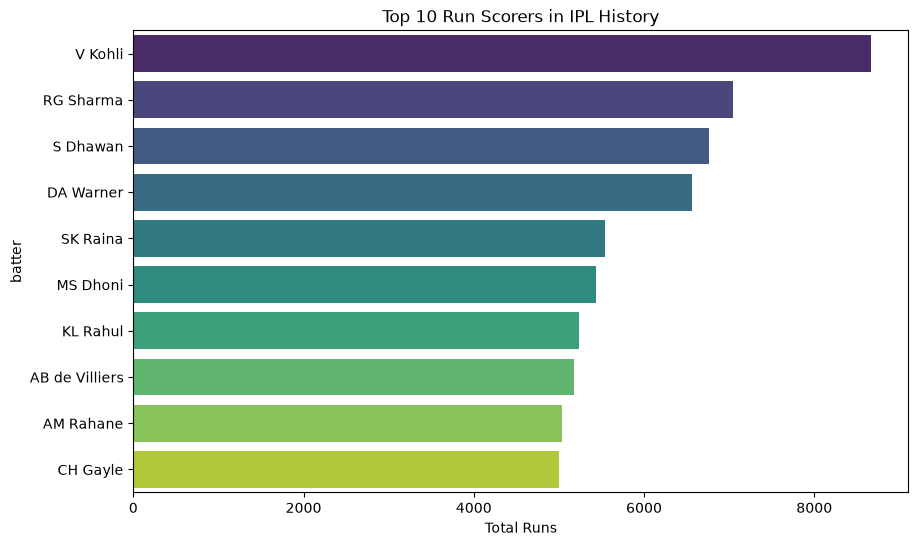

In [22]:
top_scorers = df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_scorers.values, y=top_scorers.index, palette='viridis')
plt.title('Top 10 Run Scorers in IPL History')
plt.xlabel('Total Runs')
plt.show()

# Venue wise batting first wins

In [23]:
match_level = df.drop_duplicates(subset = 'match_id')[['match_id','venue','batting_team','match_won_by','toss_decision']]


match_level.head()

,match_id,venue,batting_team,match_won_by,toss_decision
0,335982,"M Chinnaswamy Stadium, Bengaluru",Kolkata Knight Riders,Kolkata Knight Riders,field
225,335983,"Punjab Cricket Association IS Bindra Stadium, ...",Chennai Super Kings,Chennai Super Kings,bat
473,335984,"Arun Jaitley Stadium, Delhi",Rajasthan Royals,Delhi Daredevils,bat
692,335985,"Wankhede Stadium, Mumbai",Mumbai Indians,Royal Challengers Bangalore,bat
938,335986,"Eden Gardens, Kolkata",Deccan Chargers,Kolkata Knight Riders,bat


In [24]:
match_level.shape

(1169, 5)

# Effect of Toss Decision

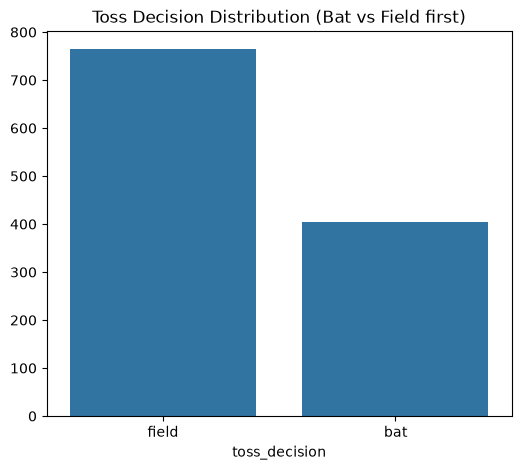

In [25]:
toss_effect = df.drop_duplicates(subset ='match_id')['toss_decision'].value_counts()

toss_effect

plt.figure(figsize=(6,5))
sns.barplot(x=toss_effect.index, y= toss_effect.values)
plt.title("Toss Decision Distribution (Bat vs Field first)")
plt.show()

# VENUE WISE BATTING WIN %

In [ ]:
# batting first team jeeti ya ni
match_level['batting_first_won'] = match_level['batting_team'] == match_level["match_won_by"]

# Venue-wise batting win %
venue_stats = match_level.groupby('venue')['batting_first_won'].agg(["mean","count"])
venue_stats.columns = ["batting_first_win_pct","matches_played"]


# Keep only those venues where atleast 10 macthes are played
venue_stats = venue_stats[venue_stats['matches_played'] >=10].sort_values('batting_first_win_pct', ascending=False)

venue_stats["batting_first_win_pct"] = (venue_stats["batting_first_win_pct"] * 100).round(1)
venue_stats.head(10)

,batting_first_win_pct,matches_played
venue,,
"Himachal Pradesh Cricket Association Stadium, Dharamsala",60.0,15
"Maharashtra Cricket Association Stadium, Pune",54.9,51
"Maharaja Yadavindra Singh International Cricket Stadium, New Chandigarh",54.5,11
"MA Chidambaram Stadium, Chepauk, Chennai",53.8,91
Kingsmead,53.3,15
"Brabourne Stadium, Mumbai",51.9,27
"Narendra Modi Stadium, Ahmedabad",48.9,45
"Arun Jaitley Stadium, Delhi",47.4,97
"Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium, Visakhapatnam",47.1,17


: 